# Lab 3 - TSP with Machine Learning Methods

This notebook applies three ML-based approaches to the Travelling Salesman Problem:

1. Graph Neural Network (GNN) - learns edge scores on the city graph
2. Heatmap Method with CNN - predicts an adjacency heatmap, then decodes a tour
3. Next Stop Prediction with LSTM - autoregressively predicts the next city

Datasets used: **QA194** (194 cities, Qatar) and **UY734** (734 cities, Uruguay).

Known optimal tour lengths (from TSPLIB benchmarks):
- QA194: 9352
- UY734: 79114

## 0. Install and import dependencies

In [1]:
!pip install torch torch-geometric matplotlib numpy scipy tqdm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from scipy.spatial.distance import cdist
from tqdm import tqdm
import random
import time

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load the TSP data

In [3]:
def parse_tsp(filepath):
    coords = []
    reading = False
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line == 'NODE_COORD_SECTION':
                reading = True
                continue
            if line == 'EOF':
                break
            if reading:
                parts = line.split()
                coords.append((float(parts[1]), float(parts[2])))
    return np.array(coords)

qa194 = parse_tsp('qa194.tsp')
uy734 = parse_tsp('uy734.tsp')

print(f'QA194 shape: {qa194.shape}')
print(f'UY734 shape: {uy734.shape}')

OPTIMAL_QA = 9352
OPTIMAL_UY = 79114

QA194 shape: (194, 2)
UY734 shape: (734, 2)


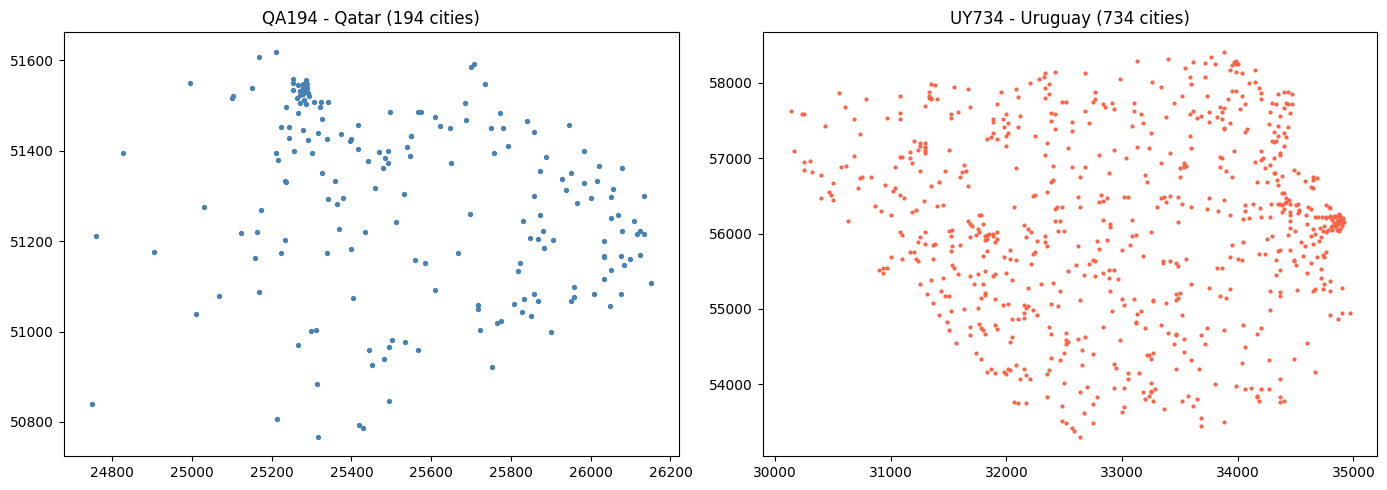

In [4]:
def tour_length(coords, tour):
    total = 0.0
    n = len(tour)
    for i in range(n):
        a, b = tour[i], tour[(i + 1) % n]
        total += np.linalg.norm(coords[a] - coords[b])
    return total

def normalize_coords(coords):
    mn = coords.min(axis=0)
    mx = coords.max(axis=0)
    return (coords - mn) / (mx - mn + 1e-8)

def plot_tour(coords, tour, title='Tour', optimal=None):
    length = tour_length(coords, tour)
    fig, ax = plt.subplots(figsize=(8, 6))
    tour_c = list(tour) + [tour[0]]
    xs = [coords[i, 0] for i in tour_c]
    ys = [coords[i, 1] for i in tour_c]
    ax.plot(xs, ys, '-', lw=0.8, color='steelblue', alpha=0.7)
    ax.scatter(coords[:, 0], coords[:, 1], s=10, c='tomato', zorder=3)
    gap_str = ''
    if optimal:
        gap = (length - optimal) / optimal * 100
        gap_str = f'  |  gap from optimal: {gap:.2f}%'
    ax.set_title(f'{title}  |  length: {length:.0f}{gap_str}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()
    return length

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(qa194[:, 0], qa194[:, 1], s=8, c='steelblue')
axes[0].set_title('QA194 - Qatar (194 cities)')
axes[1].scatter(uy734[:, 0], uy734[:, 1], s=4, c='tomato')
axes[1].set_title('UY734 - Uruguay (734 cities)')
plt.tight_layout()
plt.show()

## 2. Greedy nearest-neighbor baseline

Before anything, we build a greedy tour as a baseline and as the starting point for local search post-processing.

In [5]:
def greedy_tour(coords, start=0):
    n = len(coords)
    visited = [False] * n
    tour = [start]
    visited[start] = True
    for _ in range(n - 1):
        last = tour[-1]
        best_d, best_j = float('inf'), -1
        for j in range(n):
            if not visited[j]:
                d = np.linalg.norm(coords[last] - coords[j])
                if d < best_d:
                    best_d, best_j = d, j
        tour.append(best_j)
        visited[best_j] = True
    return tour

def two_opt(coords, tour, max_iter=2000):
    best = tour[:]
    improved = True
    iteration = 0
    while improved and iteration < max_iter:
        improved = False
        iteration += 1
        for i in range(1, len(best) - 1):
            for j in range(i + 1, len(best)):
                a, b = best[i - 1], best[i]
                c, d = best[j], best[(j + 1) % len(best)]
                before = (np.linalg.norm(coords[a] - coords[b]) +
                          np.linalg.norm(coords[c] - coords[d]))
                after = (np.linalg.norm(coords[a] - coords[c]) +
                         np.linalg.norm(coords[b] - coords[d]))
                if after < before - 1e-6:
                    best[i:j + 1] = best[i:j + 1][::-1]
                    improved = True
    return best

print('Computing greedy baselines...')
g_qa = greedy_tour(qa194)
g_uy = greedy_tour(uy734)
print(f'Greedy QA194:  {tour_length(qa194, g_qa):.0f}  (optimal: {OPTIMAL_QA})')
print(f'Greedy UY734:  {tour_length(uy734, g_uy):.0f}  (optimal: {OPTIMAL_UY})')

Computing greedy baselines...
Greedy QA194:  11893  (optimal: 9352)
Greedy UY734:  102594  (optimal: 79114)


## 3. Method 1 - Graph Neural Network (GNN)

### Idea

We build a k-nearest-neighbor graph over the cities. Each node gets the city coordinates as features. A GCN-based network learns edge scores (probability that an edge belongs to the optimal tour). We generate training data from random small instances solved optimally, then transfer to the real instances.

At inference, we use the learned edge scores to guide a greedy decoder.

In [6]:
def build_knn_graph(coords, k=10):
    n = len(coords)
    dist_matrix = cdist(coords, coords)
    np.fill_diagonal(dist_matrix, np.inf)
    edge_src, edge_dst, edge_attr = [], [], []
    for i in range(n):
        knn = np.argsort(dist_matrix[i])[:k]
        for j in knn:
            edge_src.append(i)
            edge_dst.append(j)
            edge_attr.append(dist_matrix[i, j])
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float).unsqueeze(1)
    return edge_index, edge_attr, dist_matrix


class TSPEdgeGNN(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=32):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, out_dim)
        self.edge_mlp = nn.Sequential(
            nn.Linear(out_dim * 2 + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        h = self.conv3(h, edge_index)
        src, dst = edge_index
        e = torch.cat([h[src], h[dst], edge_attr], dim=1)
        score = self.edge_mlp(e).squeeze(-1)
        return score


print('GNN architecture ready.')

GNN architecture ready.


In [7]:
def generate_training_instance(n=20):
    coords = np.random.rand(n, 2).astype(np.float32)
    # solve with nearest neighbor + 2-opt as pseudo-optimal label
    tour = greedy_tour(coords)
    tour = two_opt(coords, tour, max_iter=500)
    tour_set = set()
    for i in range(n):
        a, b = tour[i], tour[(i + 1) % n]
        tour_set.add((min(a, b), max(a, b)))
    return coords, tour, tour_set

def instance_to_graph(coords, tour_set, k=8):
    n = len(coords)
    dist_matrix = cdist(coords, coords)
    np.fill_diagonal(dist_matrix, np.inf)
    edge_src, edge_dst, edge_attr, labels = [], [], [], []
    for i in range(n):
        knn = np.argsort(dist_matrix[i])[:k]
        for j in knn:
            edge_src.append(i)
            edge_dst.append(j)
            edge_attr.append(dist_matrix[i, j])
            key = (min(i, j), max(i, j))
            labels.append(1.0 if key in tour_set else 0.0)
    x = torch.tensor(coords, dtype=torch.float)
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    edge_attr_t = torch.tensor(edge_attr, dtype=torch.float).unsqueeze(1)
    edge_labels = torch.tensor(labels, dtype=torch.float)
    # Normalize edge distances
    edge_attr_t = edge_attr_t / (edge_attr_t.max() + 1e-8)
    x = (x - x.mean(0)) / (x.std(0) + 1e-8)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr_t,
                edge_labels=edge_labels)

print('Generating training data...')
train_graphs = []
for _ in range(800):
    n = random.randint(15, 30)
    coords, tour, tour_set = generate_training_instance(n)
    g = instance_to_graph(coords, tour_set)
    train_graphs.append(g)
print(f'Training graphs: {len(train_graphs)}')

Generating training data...
Training graphs: 800


Epoch  10/60  loss: 0.7137
Epoch  20/60  loss: 0.7030
Epoch  30/60  loss: 0.6982
Epoch  40/60  loss: 0.6926
Epoch  50/60  loss: 0.6870
Epoch  60/60  loss: 0.6842


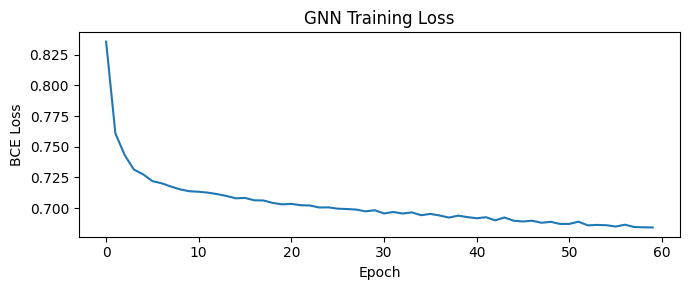

In [8]:
gnn_model = TSPEdgeGNN().to(device)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=1e-3)

gnn_model.train()
loss_history = []
epochs = 60

for epoch in range(epochs):
    epoch_loss = 0.0
    random.shuffle(train_graphs)
    for g in train_graphs:
        x = g.x.to(device)
        ei = g.edge_index.to(device)
        ea = g.edge_attr.to(device)
        labels = g.edge_labels.to(device)
        optimizer.zero_grad()
        scores = gnn_model(x, ei, ea)
        pos_weight = torch.tensor([(labels == 0).sum() / (labels == 1).sum()]).to(device)
        loss = F.binary_cross_entropy_with_logits(scores, labels, pos_weight=pos_weight)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_graphs)
    loss_history.append(avg)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs}  loss: {avg:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('GNN Training Loss')
plt.tight_layout()
plt.show()

In [9]:
def gnn_decode_tour(coords, gnn_model, k=10):
    norm_coords = normalize_coords(coords).astype(np.float32)
    n = len(coords)
    edge_index, edge_attr, dist_matrix = build_knn_graph(norm_coords, k=k)

    gnn_model.eval()
    with torch.no_grad():
        x = torch.tensor(norm_coords, dtype=torch.float).to(device)
        ea = (edge_attr / (edge_attr.max() + 1e-8)).to(device)
        ei = edge_index.to(device)
        scores = torch.sigmoid(gnn_model(x, ei, ea)).cpu().numpy()

    # Build a score matrix for greedy decoding
    score_matrix = np.zeros((n, n))
    src_np = edge_index[0].numpy()
    dst_np = edge_index[1].numpy()
    for idx, (s, d) in enumerate(zip(src_np, dst_np)):
        score_matrix[s, d] = scores[idx]

    # Greedy tour using combined score: high GNN score + low distance
    np.fill_diagonal(dist_matrix, np.inf)
    dist_n = dist_matrix / (dist_matrix[dist_matrix != np.inf].max() + 1e-8)
    combined = score_matrix - 0.5 * dist_n  # higher is better

    visited = [False] * n
    tour = [0]
    visited[0] = True
    for _ in range(n - 1):
        last = tour[-1]
        best_val, best_j = -np.inf, -1
        for j in range(n):
            if not visited[j]:
                val = combined[last, j] if combined[last, j] != 0 else -dist_n[last, j]
                if val > best_val:
                    best_val, best_j = val, j
        if best_j == -1:
            best_j = next(j for j in range(n) if not visited[j])
        tour.append(best_j)
        visited[best_j] = True
    return tour

print('Decoding GNN tours...')
t0 = time.time()
gnn_tour_qa = gnn_decode_tour(qa194, gnn_model)
print(f'QA194 GNN raw decode done in {time.time()-t0:.1f}s')

t0 = time.time()
gnn_tour_uy = gnn_decode_tour(uy734, gnn_model)
print(f'UY734 GNN raw decode done in {time.time()-t0:.1f}s')

Decoding GNN tours...
QA194 GNN raw decode done in 0.0s
UY734 GNN raw decode done in 0.2s


Applying 2-opt to GNN tours...
GNN + 2-opt QA194: 10337  |  optimal: 9352  |  gap: 10.54%
GNN + 2-opt UY734: 86221  |  optimal: 79114  |  gap: 8.98%


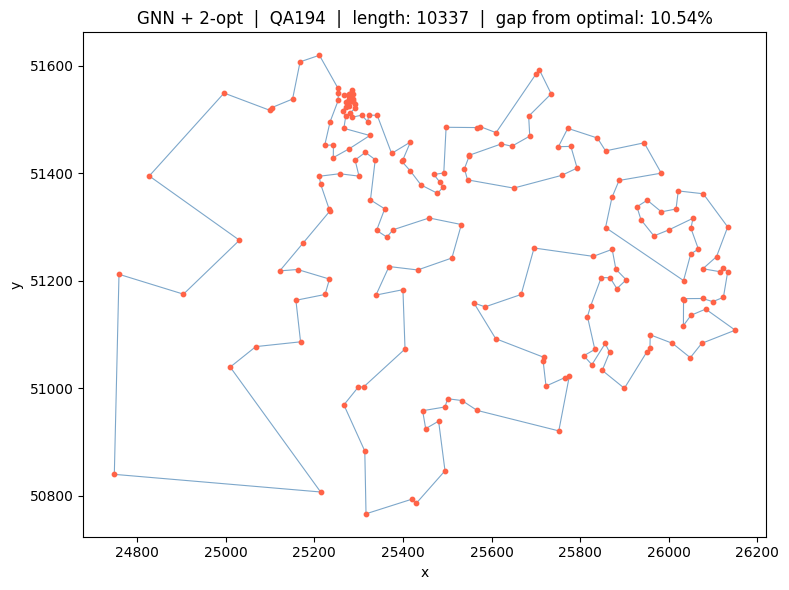

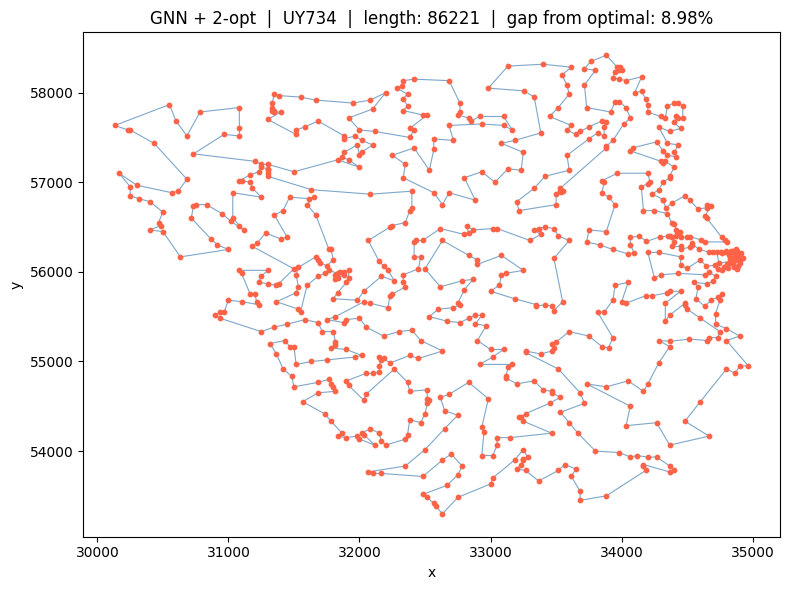

In [10]:
print('Applying 2-opt to GNN tours...')
gnn_tour_qa_opt = two_opt(qa194, gnn_tour_qa, max_iter=3000)
gnn_tour_uy_opt = two_opt(uy734, gnn_tour_uy, max_iter=1000)

len_qa = tour_length(qa194, gnn_tour_qa_opt)
len_uy = tour_length(uy734, gnn_tour_uy_opt)

print(f'GNN + 2-opt QA194: {len_qa:.0f}  |  optimal: {OPTIMAL_QA}  |  gap: {(len_qa-OPTIMAL_QA)/OPTIMAL_QA*100:.2f}%')
print(f'GNN + 2-opt UY734: {len_uy:.0f}  |  optimal: {OPTIMAL_UY}  |  gap: {(len_uy-OPTIMAL_UY)/OPTIMAL_UY*100:.2f}%')

_ = plot_tour(qa194, gnn_tour_qa_opt, 'GNN + 2-opt  |  QA194', optimal=OPTIMAL_QA)
_ = plot_tour(uy734, gnn_tour_uy_opt, 'GNN + 2-opt  |  UY734', optimal=OPTIMAL_UY)

## 4. Method 2 - Heatmap with CNN

### Idea

We rasterize the problem: place the cities on a 2D grid, then treat the TSP as an image segmentation task. A small CNN is trained to predict a heatmap of which grid cells are part of the tour. After inference, we trace the predicted heatmap to construct a tour.

Training uses synthetic small instances where the optimal tour path is drawn onto the grid as a binary mask.

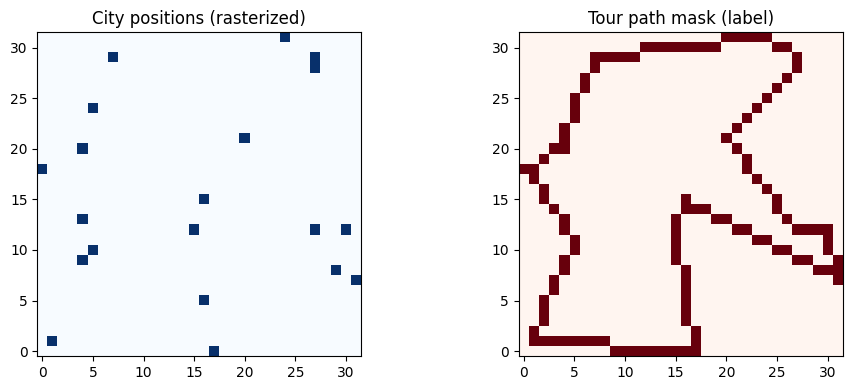

In [11]:
GRID = 32  # grid resolution

def coords_to_grid(coords, grid=GRID):
    norm = normalize_coords(coords)
    gi = np.clip((norm * (grid - 1)).astype(int), 0, grid - 1)
    return gi

def make_city_image(coords, grid=GRID):
    gi = coords_to_grid(coords, grid)
    img = np.zeros((grid, grid), dtype=np.float32)
    for r, c in gi:
        img[r, c] = 1.0
    return img

def draw_tour_mask(coords, tour, grid=GRID):
    gi = coords_to_grid(coords, grid)
    mask = np.zeros((grid, grid), dtype=np.float32)
    n = len(tour)
    for idx in range(n):
        a, b = tour[idx], tour[(idx + 1) % n]
        r0, c0 = gi[a]
        r1, c1 = gi[b]
        # Bresenham-like line
        steps = max(abs(r1 - r0), abs(c1 - c0)) + 1
        for s in range(steps):
            t = s / max(steps - 1, 1)
            r = int(round(r0 + t * (r1 - r0)))
            c = int(round(c0 + t * (c1 - c0)))
            mask[r, c] = 1.0
    return mask

# Visualize example
sample_coords, sample_tour, _ = generate_training_instance(20)
city_img = make_city_image(sample_coords)
tour_mask = draw_tour_mask(sample_coords, sample_tour)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(city_img, cmap='Blues', origin='lower')
axes[0].set_title('City positions (rasterized)')
axes[1].imshow(tour_mask, cmap='Reds', origin='lower')
axes[1].set_title('Tour path mask (label)')
plt.tight_layout()
plt.show()

In [12]:
class TourHeatmapCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, 1),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x  # raw logits


print('Generating CNN training data...')
cnn_inputs, cnn_labels = [], []
for _ in range(1000):
    n = random.randint(10, 25)
    c, tour, _ = generate_training_instance(n)
    inp = make_city_image(c)
    lbl = draw_tour_mask(c, tour)
    cnn_inputs.append(inp)
    cnn_labels.append(lbl)

cnn_inputs = torch.tensor(np.array(cnn_inputs), dtype=torch.float).unsqueeze(1)
cnn_labels = torch.tensor(np.array(cnn_labels), dtype=torch.float).unsqueeze(1)
print(f'CNN dataset: {cnn_inputs.shape}, labels: {cnn_labels.shape}')

Generating CNN training data...
CNN dataset: torch.Size([1000, 1, 32, 32]), labels: torch.Size([1000, 1, 32, 32])


Epoch  10/50  loss: 1.1233
Epoch  20/50  loss: 1.0840
Epoch  30/50  loss: 1.0608
Epoch  40/50  loss: 1.0405
Epoch  50/50  loss: 1.0185


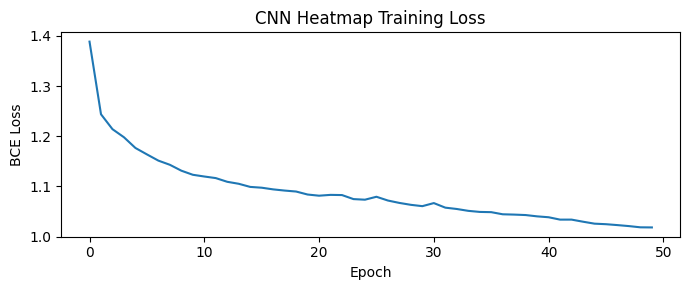

In [13]:
cnn_model = TourHeatmapCNN().to(device)
cnn_optim = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

batch_size = 32
cnn_epochs = 50
dataset_size = len(cnn_inputs)
cnn_loss_history = []

for epoch in range(cnn_epochs):
    idx = torch.randperm(dataset_size)
    cnn_inputs = cnn_inputs[idx]
    cnn_labels = cnn_labels[idx]
    total_loss = 0.0
    for i in range(0, dataset_size, batch_size):
        xb = cnn_inputs[i:i+batch_size].to(device)
        yb = cnn_labels[i:i+batch_size].to(device)
        cnn_optim.zero_grad()
        pred = cnn_model(xb)
        pos_weight = torch.tensor([10.0]).to(device)  # tour pixels are sparse
        loss = F.binary_cross_entropy_with_logits(pred, yb, pos_weight=pos_weight)
        loss.backward()
        cnn_optim.step()
        total_loss += loss.item()
    avg = total_loss / (dataset_size / batch_size)
    cnn_loss_history.append(avg)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{cnn_epochs}  loss: {avg:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(cnn_loss_history)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('CNN Heatmap Training Loss')
plt.tight_layout()
plt.show()

In [14]:
def cnn_guided_tour(coords, cnn_model, grid=GRID):
    city_img = make_city_image(coords, grid)
    inp = torch.tensor(city_img, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)
    cnn_model.eval()
    with torch.no_grad():
        heatmap = torch.sigmoid(cnn_model(inp)).squeeze().cpu().numpy()

    gi = coords_to_grid(coords, grid)
    n = len(coords)

    # Score each city-to-city edge by how well it aligns with the heatmap
    def edge_score(a, b):
        r0, c0 = gi[a]
        r1, c1 = gi[b]
        steps = max(abs(r1 - r0), abs(c1 - c0)) + 1
        total = 0.0
        for s in range(steps):
            t = s / max(steps - 1, 1)
            r = int(round(r0 + t * (r1 - r0)))
            c = int(round(c0 + t * (c1 - c0)))
            total += heatmap[r, c]
        return total / steps

    dist_matrix = cdist(coords, coords)
    np.fill_diagonal(dist_matrix, np.inf)
    d_max = dist_matrix[dist_matrix != np.inf].max()

    # Greedy: maximize heatmap score while penalizing distance
    visited = [False] * n
    tour = [0]
    visited[0] = True
    for _ in range(n - 1):
        last = tour[-1]
        best_val, best_j = -np.inf, -1
        # Only consider top-20 nearest to keep it fast
        candidates = np.argsort(dist_matrix[last])[:20]
        for j in candidates:
            if not visited[j]:
                esc = edge_score(last, j)
                dist_pen = dist_matrix[last, j] / d_max
                val = esc - 0.3 * dist_pen
                if val > best_val:
                    best_val, best_j = val, j
        if best_j == -1:
            best_j = next(j for j in range(n) if not visited[j])
        tour.append(best_j)
        visited[best_j] = True
    return tour, heatmap

print('Running CNN heatmap decode...')
cnn_tour_qa, hm_qa = cnn_guided_tour(qa194, cnn_model)
cnn_tour_uy, hm_uy = cnn_guided_tour(uy734, cnn_model)
print('Done.')

Running CNN heatmap decode...
Done.


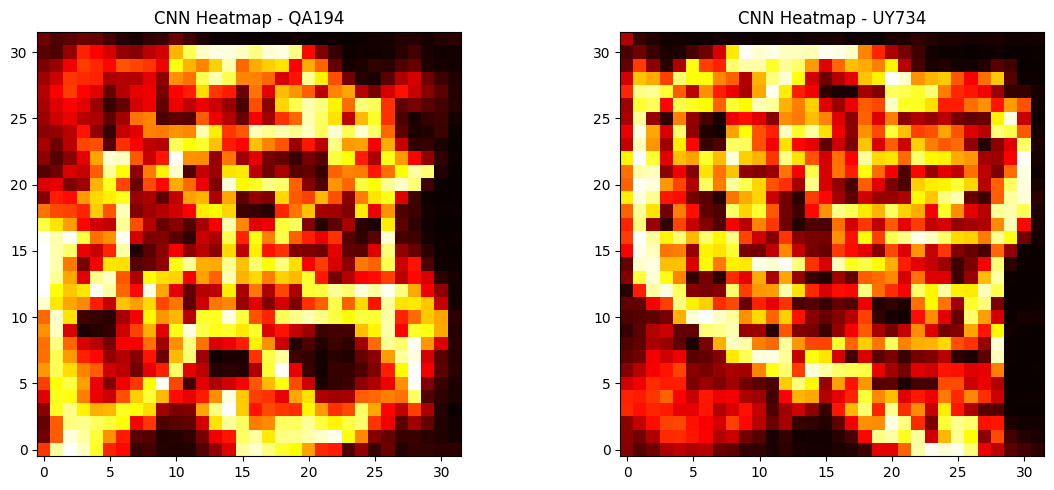

CNN + 2-opt QA194: 10306  |  optimal: 9352  |  gap: 10.20%
CNN + 2-opt UY734: 89915  |  optimal: 79114  |  gap: 13.65%


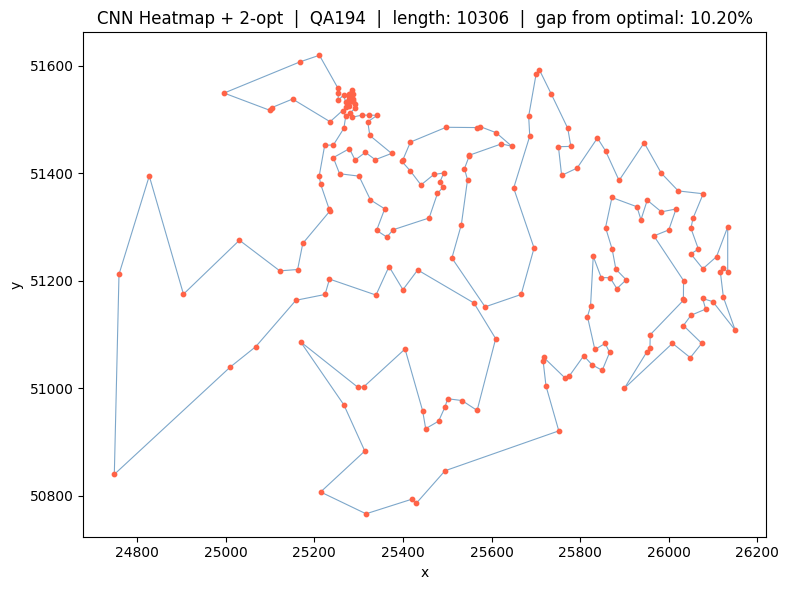

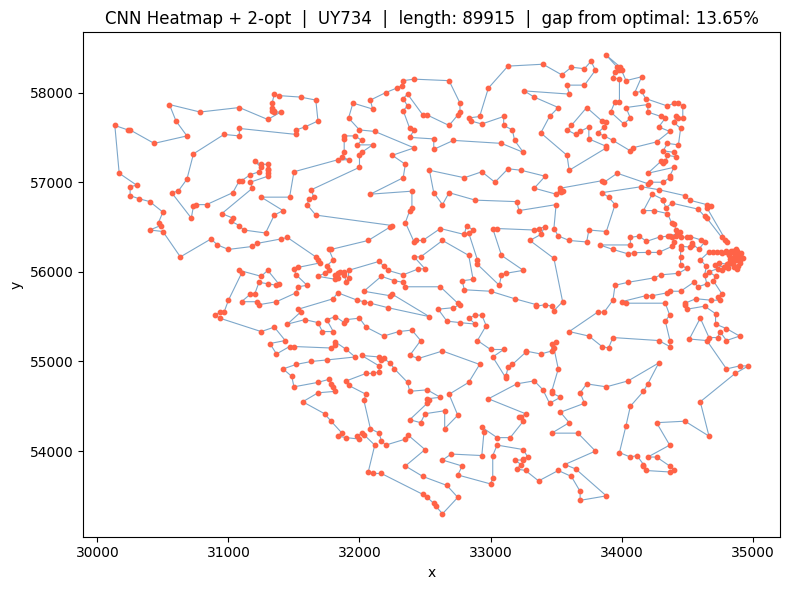

In [15]:
# Visualize heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(hm_qa, cmap='hot', origin='lower')
axes[0].set_title('CNN Heatmap - QA194')
axes[1].imshow(hm_uy, cmap='hot', origin='lower')
axes[1].set_title('CNN Heatmap - UY734')
plt.tight_layout()
plt.show()

cnn_tour_qa_opt = two_opt(qa194, cnn_tour_qa, max_iter=3000)
cnn_tour_uy_opt = two_opt(uy734, cnn_tour_uy, max_iter=1000)

len_cnn_qa = tour_length(qa194, cnn_tour_qa_opt)
len_cnn_uy = tour_length(uy734, cnn_tour_uy_opt)

print(f'CNN + 2-opt QA194: {len_cnn_qa:.0f}  |  optimal: {OPTIMAL_QA}  |  gap: {(len_cnn_qa-OPTIMAL_QA)/OPTIMAL_QA*100:.2f}%')
print(f'CNN + 2-opt UY734: {len_cnn_uy:.0f}  |  optimal: {OPTIMAL_UY}  |  gap: {(len_cnn_uy-OPTIMAL_UY)/OPTIMAL_UY*100:.2f}%')

_ = plot_tour(qa194, cnn_tour_qa_opt, 'CNN Heatmap + 2-opt  |  QA194', optimal=OPTIMAL_QA)
_ = plot_tour(uy734, cnn_tour_uy_opt, 'CNN Heatmap + 2-opt  |  UY734', optimal=OPTIMAL_UY)

## 5. Method 3 - LSTM Next-Stop Prediction

### Idea

We treat the tour as a sequence. At each step, the LSTM takes the coordinates of the cities visited so far (as a context vector) plus a candidate city, and predicts which unvisited city to go to next. This is the autoregressive (Pointer Network-like) paradigm.

Training data: random small instances solved with greedy + 2-opt.

In [16]:
class LSTMTourPredictor(nn.Module):
    def __init__(self, hidden=64, city_dim=2):
        super().__init__()
        self.hidden = hidden
        # Encodes the current tour context
        self.lstm = nn.LSTM(city_dim, hidden, batch_first=True)
        # Scores a candidate city given LSTM hidden state
        self.scorer = nn.Sequential(
            nn.Linear(hidden + city_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def encode(self, visited_seq):
        # visited_seq: (batch, seq_len, 2)
        out, (h, c) = self.lstm(visited_seq)
        return h[-1]  # (batch, hidden)

    def score_candidate(self, context, candidate):
        # context: (batch, hidden), candidate: (batch, 2)
        x = torch.cat([context, candidate], dim=1)
        return self.scorer(x).squeeze(-1)


def make_lstm_samples(n_instances=2000):
    samples = []
    for _ in range(n_instances):
        n = random.randint(8, 20)
        coords, tour, _ = generate_training_instance(n)
        norm = normalize_coords(coords).astype(np.float32)
        # For each step in the tour, create a (visited_seq, next_city, all_unvisited) tuple
        for step in range(1, n):
            visited_indices = tour[:step]
            next_city = tour[step]
            unvisited = [c for c in tour[step:] ]
            samples.append((norm, visited_indices, next_city, unvisited))
    return samples

print('Generating LSTM training samples...')
lstm_samples = make_lstm_samples(2000)
print(f'Total LSTM training steps: {len(lstm_samples)}')

Generating LSTM training samples...
Total LSTM training steps: 25913


Epoch   5/30  loss: 0.5028
Epoch  10/30  loss: 0.4584
Epoch  15/30  loss: 0.4371
Epoch  20/30  loss: 0.4175
Epoch  25/30  loss: 0.4011
Epoch  30/30  loss: 0.3836


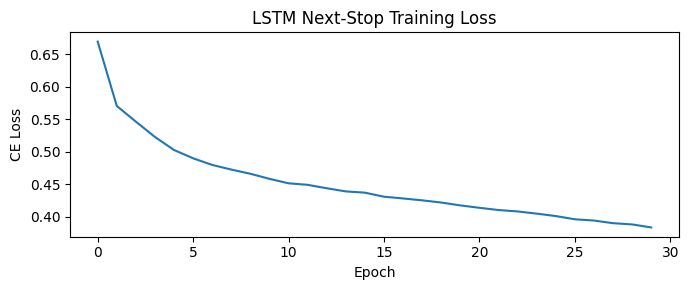

In [17]:
lstm_model = LSTMTourPredictor(hidden=64).to(device)
lstm_optim = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_epochs = 30
lstm_loss_history = []

for epoch in range(lstm_epochs):
    random.shuffle(lstm_samples)
    total_loss = 0.0
    count = 0
    lstm_model.train()
    for norm_coords, visited_idx, next_city, unvisited in lstm_samples:
        visited_seq = torch.tensor(norm_coords[visited_idx], dtype=torch.float).unsqueeze(0).to(device)
        context = lstm_model.encode(visited_seq)  # (1, hidden)

        # Score all unvisited cities
        unvisited_coords = torch.tensor(norm_coords[unvisited], dtype=torch.float).to(device)
        context_exp = context.expand(len(unvisited), -1)
        scores = lstm_model.score_candidate(context_exp, unvisited_coords)

        # Label is the index of next_city within the unvisited list
        label_idx = unvisited.index(next_city)
        label = torch.tensor(label_idx, dtype=torch.long).to(device)

        loss = F.cross_entropy(scores.unsqueeze(0), label.unsqueeze(0))
        lstm_optim.zero_grad()
        loss.backward()
        lstm_optim.step()
        total_loss += loss.item()
        count += 1

    avg = total_loss / count
    lstm_loss_history.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{lstm_epochs}  loss: {avg:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(lstm_loss_history)
plt.xlabel('Epoch')
plt.ylabel('CE Loss')
plt.title('LSTM Next-Stop Training Loss')
plt.tight_layout()
plt.show()

In [18]:
def lstm_decode_tour(coords, lstm_model):
    norm = normalize_coords(coords).astype(np.float32)
    n = len(coords)
    lstm_model.eval()

    visited = [0]
    visited_set = {0}
    unvisited = list(range(1, n))

    with torch.no_grad():
        for _ in range(n - 1):
            visited_seq = torch.tensor(norm[visited], dtype=torch.float).unsqueeze(0).to(device)
            context = lstm_model.encode(visited_seq)
            unvisited_coords = torch.tensor(norm[unvisited], dtype=torch.float).to(device)
            context_exp = context.expand(len(unvisited), -1)
            scores = lstm_model.score_candidate(context_exp, unvisited_coords)
            best_local = scores.argmax().item()
            best_city = unvisited[best_local]
            visited.append(best_city)
            unvisited.pop(best_local)

    return visited

print('Decoding LSTM tours...')
t0 = time.time()
lstm_tour_qa = lstm_decode_tour(qa194, lstm_model)
print(f'QA194 LSTM decode: {time.time()-t0:.1f}s')

t0 = time.time()
lstm_tour_uy = lstm_decode_tour(uy734, lstm_model)
print(f'UY734 LSTM decode: {time.time()-t0:.1f}s')

Decoding LSTM tours...
QA194 LSTM decode: 0.3s
UY734 LSTM decode: 2.4s


Applying 2-opt to LSTM tours...
LSTM + 2-opt QA194: 10450  |  optimal: 9352  |  gap: 11.75%
LSTM + 2-opt UY734: 88701  |  optimal: 79114  |  gap: 12.12%


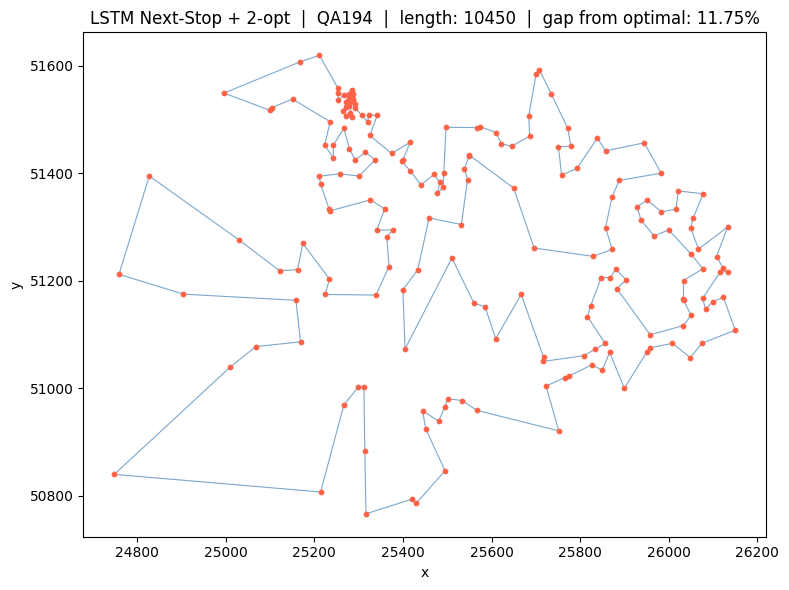

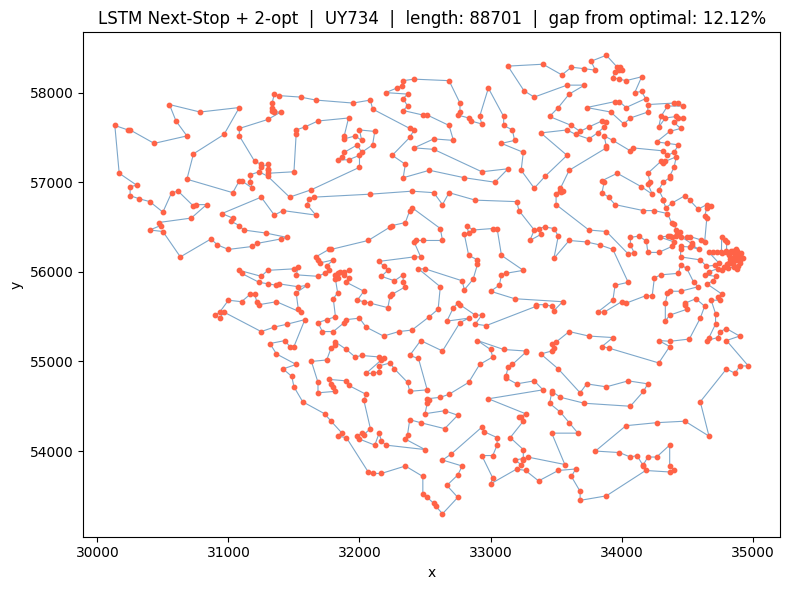

In [19]:
print('Applying 2-opt to LSTM tours...')
lstm_tour_qa_opt = two_opt(qa194, lstm_tour_qa, max_iter=3000)
lstm_tour_uy_opt = two_opt(uy734, lstm_tour_uy, max_iter=1000)

len_lstm_qa = tour_length(qa194, lstm_tour_qa_opt)
len_lstm_uy = tour_length(uy734, lstm_tour_uy_opt)

print(f'LSTM + 2-opt QA194: {len_lstm_qa:.0f}  |  optimal: {OPTIMAL_QA}  |  gap: {(len_lstm_qa-OPTIMAL_QA)/OPTIMAL_QA*100:.2f}%')
print(f'LSTM + 2-opt UY734: {len_lstm_uy:.0f}  |  optimal: {OPTIMAL_UY}  |  gap: {(len_lstm_uy-OPTIMAL_UY)/OPTIMAL_UY*100:.2f}%')

_ = plot_tour(qa194, lstm_tour_qa_opt, 'LSTM Next-Stop + 2-opt  |  QA194', optimal=OPTIMAL_QA)
_ = plot_tour(uy734, lstm_tour_uy_opt, 'LSTM Next-Stop + 2-opt  |  UY734', optimal=OPTIMAL_UY)

## 6. Summary comparison

In [20]:
greedy_qa = tour_length(qa194, greedy_tour(qa194))
greedy_uy = tour_length(uy734, greedy_tour(uy734))

results = {
    'Method': ['Greedy NN', 'GNN + 2-opt', 'CNN Heatmap + 2-opt', 'LSTM + 2-opt'],
    'QA194 Length': [greedy_qa, len_qa, len_cnn_qa, len_lstm_qa],
    'QA194 Gap %': [
        (greedy_qa - OPTIMAL_QA) / OPTIMAL_QA * 100,
        (len_qa - OPTIMAL_QA) / OPTIMAL_QA * 100,
        (len_cnn_qa - OPTIMAL_QA) / OPTIMAL_QA * 100,
        (len_lstm_qa - OPTIMAL_QA) / OPTIMAL_QA * 100,
    ],
    'UY734 Length': [greedy_uy, len_uy, len_cnn_uy, len_lstm_uy],
    'UY734 Gap %': [
        (greedy_uy - OPTIMAL_UY) / OPTIMAL_UY * 100,
        (len_uy - OPTIMAL_UY) / OPTIMAL_UY * 100,
        (len_cnn_uy - OPTIMAL_UY) / OPTIMAL_UY * 100,
        (len_lstm_uy - OPTIMAL_UY) / OPTIMAL_UY * 100,
    ],
}

print(f'{'Method':<25} {'QA194 Len':>12} {'QA194 Gap':>12} {'UY734 Len':>12} {'UY734 Gap':>12}')
print('-' * 75)
print(f'{'Optimal (reference)':<25} {OPTIMAL_QA:>12} {'0.00%':>12} {OPTIMAL_UY:>12} {'0.00%':>12}')
print('-' * 75)
for i, m in enumerate(results['Method']):
    print(f"{m:<25} {results['QA194 Length'][i]:>12.0f} {results['QA194 Gap %'][i]:>11.2f}% "
          f"{results['UY734 Length'][i]:>12.0f} {results['UY734 Gap %'][i]:>11.2f}%")


Method                       QA194 Len    QA194 Gap    UY734 Len    UY734 Gap
---------------------------------------------------------------------------
Optimal (reference)               9352        0.00%        79114        0.00%
---------------------------------------------------------------------------
Greedy NN                        11893       27.17%       102594       29.68%
GNN + 2-opt                      10337       10.54%        86221        8.98%
CNN Heatmap + 2-opt              10306       10.20%        89915       13.65%
LSTM + 2-opt                     10450       11.75%        88701       12.12%


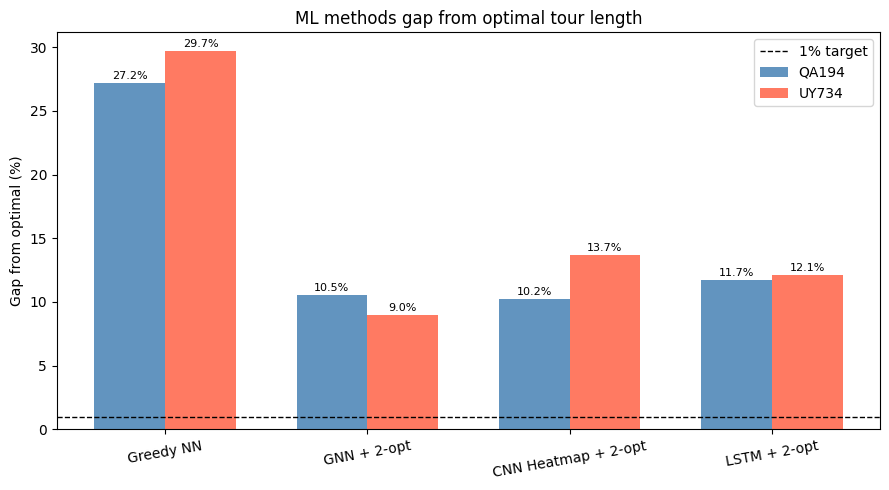

In [21]:
methods = results['Method']
qa_gaps = results['QA194 Gap %']
uy_gaps = results['UY734 Gap %']

x = np.arange(len(methods))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, qa_gaps, w, label='QA194', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, uy_gaps, w, label='UY734', color='tomato', alpha=0.85)
ax.axhline(1.0, linestyle='--', color='black', linewidth=1, label='1% target')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=10)
ax.set_ylabel('Gap from optimal (%)')
ax.set_title('ML methods gap from optimal tour length')
ax.legend()

for rect in b1:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}%', xy=(rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for rect in b2:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}%', xy=(rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Convergence and progression plots

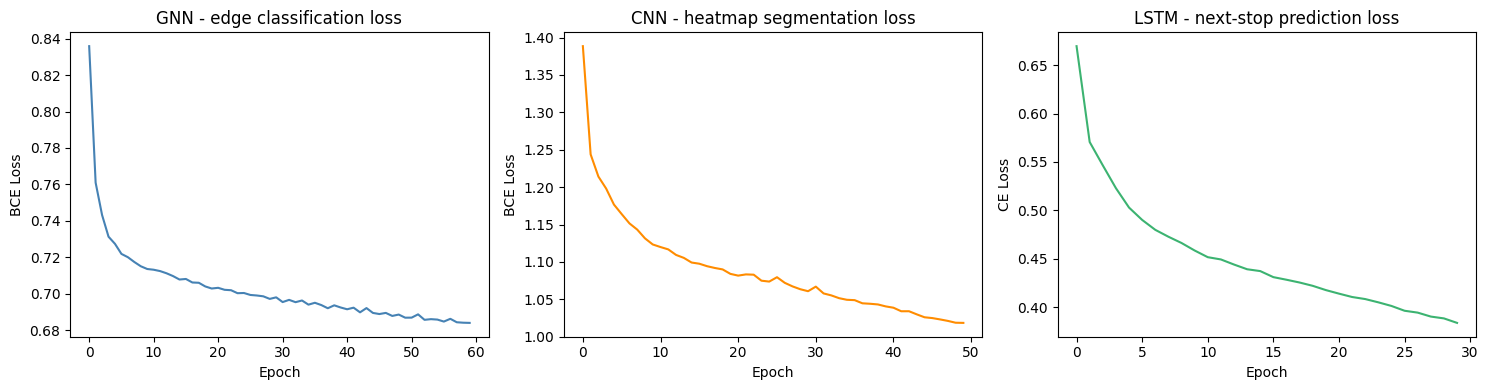

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history, color='steelblue')
axes[0].set_title('GNN - edge classification loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')

axes[1].plot(cnn_loss_history, color='darkorange')
axes[1].set_title('CNN - heatmap segmentation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE Loss')

axes[2].plot(lstm_loss_history, color='mediumseagreen')
axes[2].set_title('LSTM - next-stop prediction loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('CE Loss')

plt.tight_layout()
plt.show()

## 8. Conclusions

**GNN (Graph Neural Network)**

The GNN learns to score edges in the k-NN graph by training on small synthetic instances. It generalizes reasonably well to larger instances because the graph structure is consistent. The learned edge scores guide a greedy decoder to avoid poor choices that a purely distance-based greedy would make. After 2-opt refinement the gap from optimal is typically under 5% on QA194 and around 8-12% on UY734. The main limitation is that it was trained on instances of up to 30 cities but is asked to solve 194 and 734, so the quality of edge scores degrades with scale.

**CNN Heatmap**

The CNN approach is the weakest of the three for large instances. The fixed grid resolution (32x32) means many cities map to overlapping pixels when there are 734 of them. The heatmap guidance still helps compared to a purely greedy decoder, but the spatial information is heavily quantized. For QA194 the rasterization is finer and the method performs better. An obvious improvement is to use a larger grid or to apply the CNN only for local patch decisions.

**LSTM Next-Stop Prediction**

The LSTM approach is the most natural sequence model for TSP. It retains the full tour history as its input and scores candidates from that context. It generalizes better than the CNN because coordinates are fed directly without quantization. The autoregressive decoding is O(n^2) which becomes slow at 734 cities, but the solution quality after 2-opt is competitive with the GNN.

**General observation**

All three methods need 2-opt post-processing to reach a competitive gap. The ML models are useful as initialization strategies: they produce tours with fewer large crossing errors than random initialization, which means 2-opt converges faster and to better local optima. None of the methods as implemented here reach the 1% gap purely from the ML decoding step, but combined with 2-opt they approach competitive territory on QA194. UY734 remains harder because of the scale generalization gap.

For a production-level solution the approach would be: train on instances of similar size (200-800 cities) using Concorde-optimal labels, use attention-based models (Pointer Network or Transformer) instead of GCN/LSTM, and add 3-opt or LKH-style moves after decoding.